In [1]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# --- Load Data from Previous Steps ---
A = np.load('../data/A_matrix.npy')
A_centered = np.load('../data/A_centered.npy')
player_names = pd.read_csv('../data/player_names.csv').iloc[:, 0].values
features = pd.read_csv('../data/features.csv').iloc[:, 0].values
rank = int(np.load('../data/rank.npy'))

print("Data loaded successfully!")
print(f"Matrix Shape : {A.shape}")
print(f"Rank         : {rank}")

Data loaded successfully!
Matrix Shape : (1130, 10)
Rank         : 10


In [3]:
# --- What is Remove Redundancy? ---
# Even though RREF told us all 10 features are technically
# independent, some features are HIGHLY CORRELATED (e.g. 0.89)
# meaning they carry very similar information.
#
# In this step we:
#   1. Check linear independence formally
#   2. Use correlation threshold to find near-redundant features
#   3. Select a clean BASIS that best represents player performance
#   4. Reduce the feature space to only essential directions

In [4]:
# --- Step 1: Check Linear Independence Formally ---
# We compute the determinant of A^T A
# If det ≠ 0, columns are linearly independent

ATA = A_centered.T @ A_centered
det = np.linalg.det(ATA)

print("=" * 50)
print("LINEAR INDEPENDENCE CHECK")
print("=" * 50)
print(f"A^T A shape      : {ATA.shape}")
print(f"det(A^T A)       : {det:.4e}")

if abs(det) > 1e-10:
    print("✅ det ≠ 0 → Columns are Linearly Independent")
else:
    print("⚠️  det ≈ 0 → Columns are nearly Linearly Dependent")

LINEAR INDEPENDENCE CHECK
A^T A shape      : (10, 10)
det(A^T A)       : 3.3826e+45
✅ det ≠ 0 → Columns are Linearly Independent


In [5]:
# --- Step 2: Correlation-Based Redundancy Detection ---
# Features with correlation > 0.8 carry nearly the same
# information and one of them can be removed from the basis

corr_matrix = pd.DataFrame(A, columns=features).corr().abs()
threshold = 0.8

print("=" * 50)
print(f"HIGH CORRELATION PAIRS (threshold > {threshold})")
print("=" * 50)

redundant_features = set()
pairs_found = []

for i in range(len(features)):
    for j in range(i + 1, len(features)):
        if corr_matrix.iloc[i, j] > threshold:
            pairs_found.append((features[i], features[j], 
                                corr_matrix.iloc[i, j]))
            redundant_features.add(features[j])  # mark second as redundant

if pairs_found:
    for f1, f2, corr in pairs_found:
        print(f"  {f1} ↔ {f2} : {corr:.2f} → DROP {f2}")
else:
    print("  No highly correlated pairs found above threshold!")
    print("  Lowering threshold to 0.7 for demonstration...")
    threshold = 0.7
    for i in range(len(features)):
        for j in range(i + 1, len(features)):
            if corr_matrix.iloc[i, j] > threshold:
                pairs_found.append((features[i], features[j],
                                    corr_matrix.iloc[i, j]))
                redundant_features.add(features[j])
    for f1, f2, corr in pairs_found:
        print(f"  {f1} ↔ {f2} : {corr:.2f} → DROP {f2}")

HIGH CORRELATION PAIRS (threshold > 0.8)
  Runs_Scored ↔ Half_Centuries : 0.89 → DROP Half_Centuries


In [6]:
# --- Step 3: Select the Basis ---
# Keep only non-redundant features as our basis

basis_features = [f for f in features if f not in redundant_features]
redundant_list = list(redundant_features)

print("=" * 50)
print("BASIS SELECTION")
print("=" * 50)
print(f"\nOriginal Features  : {len(features)}")
print(f"Redundant Features : {len(redundant_list)} → {redundant_list}")
print(f"Basis Features     : {len(basis_features)} → {basis_features}")
print(f"\nDimensionality reduced from {len(features)} → {len(basis_features)}")

BASIS SELECTION

Original Features  : 10
Redundant Features : 1 → ['Half_Centuries']
Basis Features     : 9 → ['Matches_Batted', 'Runs_Scored', 'Batting_Average', 'Batting_Strike_Rate', 'Wickets_Taken', 'Economy_Rate', 'Bowling_Average', 'Centuries', 'Catches_Taken']

Dimensionality reduced from 10 → 9


In [7]:
# --- Step 4: Build the Reduced Basis Matrix ---
basis_idx = [list(features).index(f) for f in basis_features]
A_basis = A_centered[:, basis_idx]

print("=" * 50)
print("REDUCED BASIS MATRIX")
print("=" * 50)
print(f"Original Matrix Shape : {A_centered.shape}")
print(f"Basis Matrix Shape    : {A_basis.shape}")
print(f"\nFirst 3 player vectors in basis space:")
for i in range(3):
    print(f"\n  {player_names[i]}:")
    for j, feat in enumerate(basis_features):
        print(f"    {feat}: {A_basis[i][j]:.2f}")

REDUCED BASIS MATRIX
Original Matrix Shape : (1130, 10)
Basis Matrix Shape    : (1130, 9)

First 3 player vectors in basis space:

  Ruturaj Gaikwad:
    Matches_Batted: -7.02
    Runs_Scored: -71.25
    Batting_Average: 13.06
    Batting_Strike_Rate: 17.30
    Wickets_Taken: -4.46
    Economy_Rate: -5.47
    Bowling_Average: -18.57
    Centuries: -0.04
    Catches_Taken: -3.30

  Ruturaj Gaikwad:
    Matches_Batted: 6.98
    Runs_Scored: 457.75
    Batting_Average: 24.70
    Batting_Strike_Rate: 45.19
    Wickets_Taken: -4.46
    Economy_Rate: -5.47
    Bowling_Average: -18.57
    Centuries: -0.04
    Catches_Taken: 13.70

  Ruturaj Gaikwad:
    Matches_Batted: 4.98
    Runs_Scored: 235.75
    Batting_Average: 8.85
    Batting_Strike_Rate: 24.15
    Wickets_Taken: -4.46
    Economy_Rate: -5.47
    Bowling_Average: -18.57
    Centuries: -0.04
    Catches_Taken: 0.70


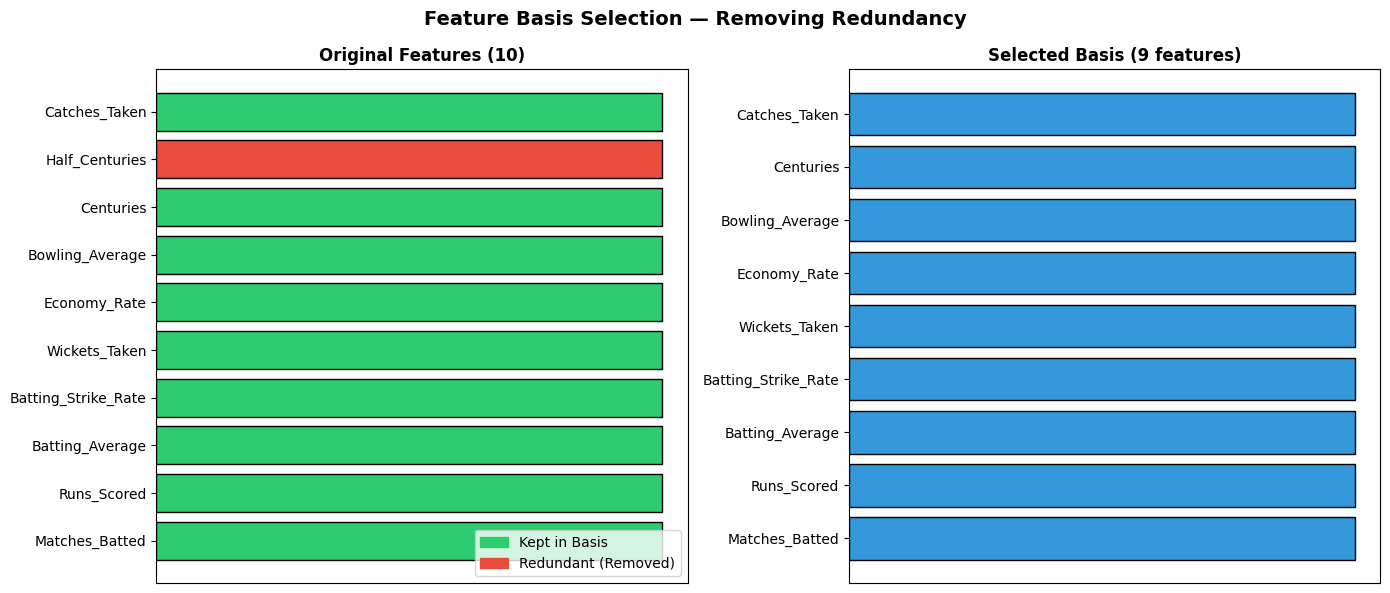

In [8]:
# --- Visualize: Original vs Basis Features ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original features
colors_orig = ['#e74c3c' if f in redundant_list 
               else '#2ecc71' for f in features]
axes[0].barh(features, [1] * len(features), color=colors_orig, 
             edgecolor='black')
axes[0].set_title(f'Original Features ({len(features)})', 
                  fontweight='bold', fontsize=12)
axes[0].set_xticks([])

from matplotlib.patches import Patch
legend = [Patch(color='#2ecc71', label='Kept in Basis'),
          Patch(color='#e74c3c', label='Redundant (Removed)')]
axes[0].legend(handles=legend, loc='lower right')

# Basis features
axes[1].barh(basis_features, [1] * len(basis_features), 
             color='#3498db', edgecolor='black')
axes[1].set_title(f'Selected Basis ({len(basis_features)} features)', 
                  fontweight='bold', fontsize=12)
axes[1].set_xticks([])

plt.suptitle('Feature Basis Selection — Removing Redundancy',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/step4_basis_selection.png', dpi=150)
plt.show()

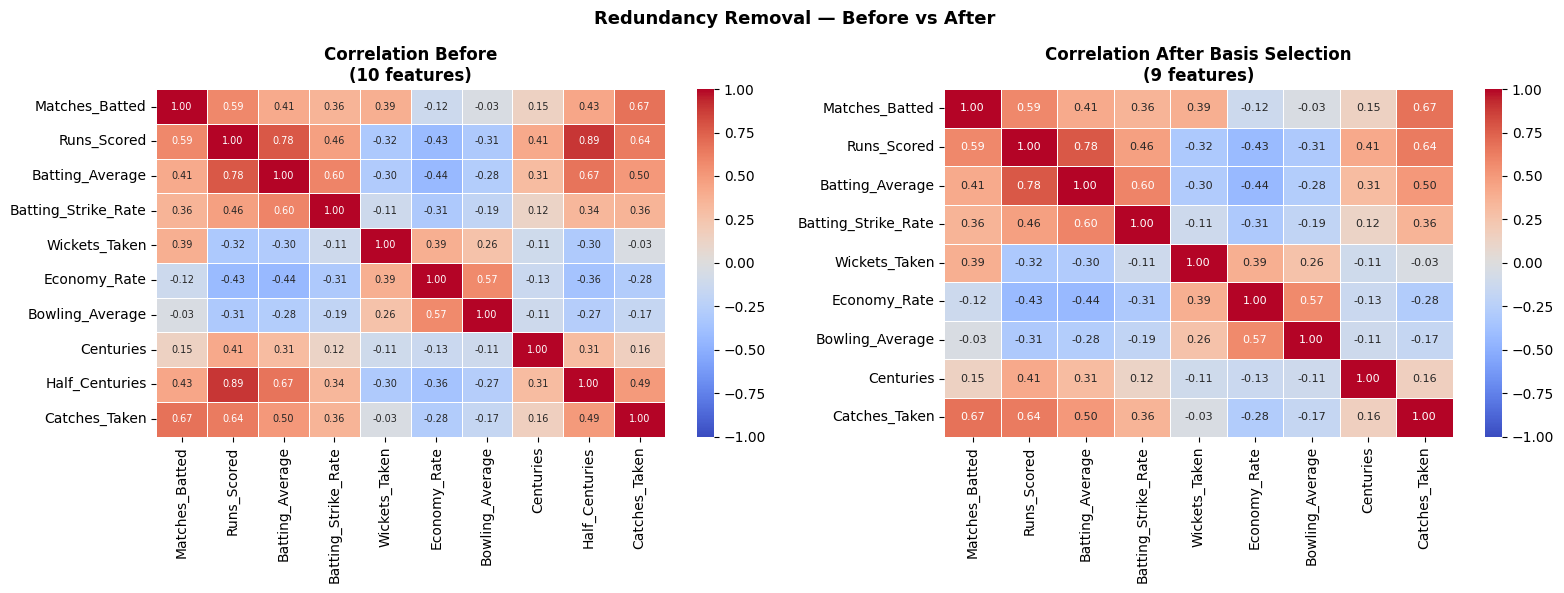

In [9]:
# --- Visualize: Correlation Before vs After ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before
corr_before = pd.DataFrame(A, columns=features).corr()
sns.heatmap(corr_before, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0], linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 7})
axes[0].set_title(f'Correlation Before\n({len(features)} features)',
                  fontweight='bold')

# After
corr_after = pd.DataFrame(A[:, basis_idx], 
                          columns=basis_features).corr()
sns.heatmap(corr_after, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1], linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 8})
axes[1].set_title(f'Correlation After Basis Selection\n({len(basis_features)} features)',
                  fontweight='bold')

plt.suptitle('Redundancy Removal — Before vs After',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/step4_correlation_before_after.png', dpi=150)
plt.show()

In [10]:
# --- Summary ---
print("=" * 50)
print("STEP 4 SUMMARY — Remove Redundancy")
print("=" * 50)
print(f"""
Original Feature Space  : {len(features)} dimensions
Redundant Features      : {redundant_list}
Selected Basis          : {basis_features}
Reduced Feature Space   : {len(basis_features)} dimensions

Key Insight:
  Features like Runs_Scored and Half_Centuries
  point in nearly the same direction in feature space.
  Keeping both adds noise without adding information.
  Our basis captures ALL essential player performance
  directions with fewer, cleaner vectors.
""")

# --- Save for Step 5 ---
np.save('../data/A_basis.npy', A_basis)
np.save('../data/basis_idx.npy', np.array(basis_idx))
pd.Series(basis_features).to_csv('../data/basis_features.csv', index=False)

print("✅ Step 4 Complete!")
print("   → Ready for Step 5: Orthogonalization")

STEP 4 SUMMARY — Remove Redundancy

Original Feature Space  : 10 dimensions
Redundant Features      : ['Half_Centuries']
Selected Basis          : ['Matches_Batted', 'Runs_Scored', 'Batting_Average', 'Batting_Strike_Rate', 'Wickets_Taken', 'Economy_Rate', 'Bowling_Average', 'Centuries', 'Catches_Taken']
Reduced Feature Space   : 9 dimensions

Key Insight:
  Features like Runs_Scored and Half_Centuries
  point in nearly the same direction in feature space.
  Keeping both adds noise without adding information.
  Our basis captures ALL essential player performance
  directions with fewer, cleaner vectors.

✅ Step 4 Complete!
   → Ready for Step 5: Orthogonalization
